# Assignment 6

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:
    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).

``Objectives``

* This assignment connects all the pieces involved in training feed-forward fully connected neural networks (FFNN); 

* You will run a full set of experiments to explore different hyperparameters and hidden layer sizes for two datasets, and then document your findings.

``Data``
* Digits MNIST
* Fashion MNIST

### Import libraries

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns  # for nicer plots
sns.set(style="darkgrid")  # default style

import tensorflow as tf
from tensorflow import keras
from keras import metrics

from keras.datasets import fashion_mnist
from keras.datasets import mnist

tf.get_logger().setLevel('INFO')

---
### Step 1: Data ingestion

In [2]:
# Load the Fashion MNIST dataset.
(X_train_fashion, Y_train_fashion), (X_test_fashion, Y_test_fashion) = fashion_mnist.load_data()

# Load the Digits MNIST dataset.
(X_train_digits, Y_train_digits), (X_test_digits, Y_test_digits) = mnist.load_data()

---
### Step 2: Data preprocessing

``Fashion MNIST``

In [3]:
# Normalize
X_train_fashion = X_train_fashion / 255.
X_test_fashion = X_test_fashion / 255.

# Flatten Y_train and Y_test, so they become vectors of label values.
Y_train_fashion = Y_train_fashion.flatten()
Y_test_fashion = Y_test_fashion.flatten()

label_names = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
               'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

# Apply random shufflying to training examples.
np.random.seed(0)
indices = np.arange(X_train_fashion.shape[0])
shuffled_indices = np.random.permutation(indices)
X_train_fashion = X_train_fashion[shuffled_indices]
Y_train_fashion = Y_train_fashion[shuffled_indices]

``Digits MNIST``

In [4]:
# Normalize
X_train_digits = X_train_digits / 255.
X_test_digits = X_test_digits / 255.

# Flatten Y_train and Y_test, so they become vectors of label values.
Y_train_digits = Y_train_digits.flatten()
Y_test_digits = Y_test_digits.flatten()

# Apply random shufflying to training examples.
np.random.seed(0)
indices = np.arange(X_train_digits.shape[0])
shuffled_indices = np.random.permutation(indices)
X_train_digits = X_train_digits[shuffled_indices]
Y_train_digits = Y_train_digits[shuffled_indices]

print(f"{X_train_digits.shape}")

(60000, 28, 28)


---
### Step 3: Exploratory data analysis (EDA)

### <span style="color:chocolate">Exercise 1:</span> Getting to know your data (5 points)

Complete the following task:

1. Show the first training example in X_train_fashion;
2. Show the first training example in X_train_digits;
3. Display the first 5 images in X_train_digits for each class in Y_train_digits, arranged in a 10x5 grid. 

### 1. First Training Example of X_train_fashion

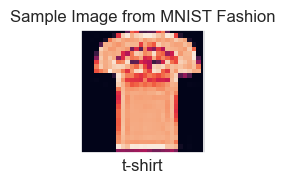

In [5]:
fig, ax = plt.subplots(figsize=(2, 2))
ax.imshow(X_train_fashion[0])
ax.set_yticks([])
ax.set_xticks([])
ax.set_title("Sample Image from MNIST Fashion", size=12)
ax.set_xlabel(label_names[Y_train_fashion[0]])
plt.tight_layout(pad=1.08, h_pad=None, w_pad=None, rect=None)
plt.show()

### 2. First Training Example of X_train_digits

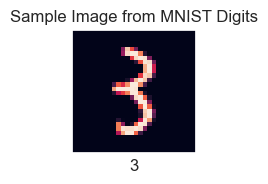

In [6]:
fig, ax = plt.subplots(figsize=(2, 2))
ax.imshow(X_train_digits[0])
ax.set_yticks([])
ax.set_xticks([])
ax.set_title("Sample Image from MNIST Digits", size=12)
ax.set_xlabel(Y_train_digits[0])
plt.tight_layout(pad=1.08, h_pad=None, w_pad=None, rect=None)
plt.show()

### 3. Grid of X_train_digits

In [7]:
display_images = [[] for _ in range(10)]

for label_index in range(10):
    target = 5
    for image_index in range(len(Y_train_digits)):
        if target < 1:
            break
        if Y_train_digits[image_index] == label_index:
            display_images[label_index].append(X_train_digits[image_index])
            target -= 1

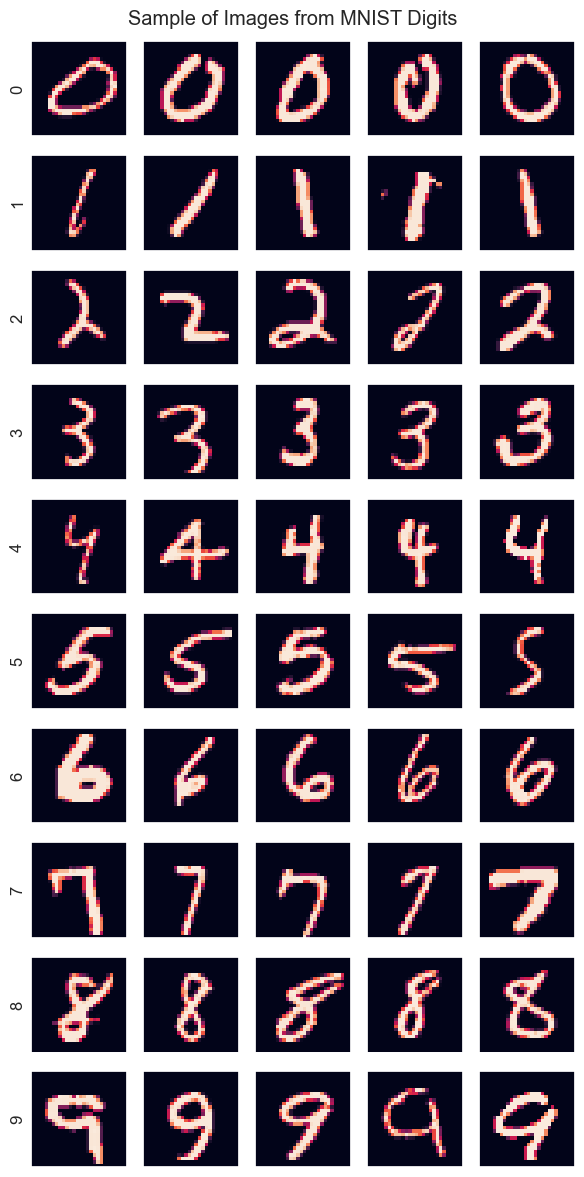

In [8]:
fig, axes = plt.subplots(10, 5, figsize=(6, 12))

for label_index, label_images in enumerate(display_images):
    for image_index in range(5):
        ax = axes[label_index, image_index]
        ax.imshow(label_images[image_index])
        ax.get_xaxis().set_visible(False)
        ax.set_yticks([])
for digit, ax in enumerate(axes[:,0]):
    ax.set_ylabel(digit, size=12)
fig.suptitle("Sample of Images from MNIST Digits")
plt.tight_layout(pad=1.08, h_pad=None, w_pad=None, rect=None)
plt.show()

### Step 4: Modeling

### <span style="color:chocolate">Exercise 2:</span> Define model (20 points)

1. Fill in the <span style="color:chocolate">build_model()</span> function below, including all the arguments listed in the function definition. Note: the activation function parameter is only for the the hidden layers; use the appropriate final classification function for the final layer.

In [9]:
def build_model(n_classes,
                hidden_layer_sizes=[],
                activation='relu',
                optimizer='SGD',
                learning_rate=0.01,
                metric='metric'):
    """Build a multi-class logistic regression model using Keras.

    Args:
    n_classes: Number of output classes in the dataset.
    hidden_layer_sizes: A list with the number of units in each hidden layer.
    activation: The activation function to use for the hidden layers.
    optimizer: The optimizer to use (SGD, Adam).
    learning_rate: The desired learning rate for the optimizer.
    metric: The desired metric.

    Returns:
    model: A tf.keras model (graph).
    """
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)

    model = tf.keras.Sequential()
    for i, layer_units in enumerate(hidden_layer_sizes):
        if i == 0:
            layer = tf.keras.layers.Dense(
                units=layer_units,
                input_shape=(784,),
                use_bias=True,
                activation=activation,
                kernel_initializer=tf.initializers.RandomNormal(stddev=0.01),
                bias_initializer=tf.initializers.RandomNormal(stddev=0.01)
            )
        else:
            layer = tf.keras.layers.Dense(
                units=layer_units,
                use_bias=True,
                activation=activation,
                kernel_initializer=tf.initializers.RandomNormal(stddev=0.01),
                bias_initializer=tf.initializers.RandomNormal(stddev=0.01)
            )
        model.add(layer)
    
    model.add(tf.keras.layers.Dense(
        units=n_classes,
        use_bias=True,
        activation='softmax',
        kernel_initializer=tf.initializers.RandomNormal(stddev=0.01),
        bias_initializer=tf.initializers.RandomNormal(stddev=0.01)
        )
    )

    if optimizer == "SGD":
        keras_optimizer = tf.keras.optimizers.legacy.SGD(learning_rate=learning_rate)
    elif optimizer == "Adam":
        keras_optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=learning_rate)
    else:
        keras_optimizer = optimizer

    model.compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        optimizer=keras_optimizer,
        metrics=[metric]
    )
    
    return model

---
### Step 5: Experiments

You can now run a suite of experiments to see how the hyperparameters and layer sizes effect model performance. 

The <span style="color:chocolate">train_and_evaluate()</span> function below can be used to run experiments and retrieve results.

In [10]:
# Reshape X_train, X_test

X_train_digits = X_train_digits.reshape(X_train_digits.shape[0], 784)
X_test_digits = X_test_digits.reshape(X_test_digits.shape[0], 784)
X_train_fashion = X_train_fashion.reshape(X_train_fashion.shape[0], 784)
X_test_fashion = X_test_fashion.reshape(X_test_fashion.shape[0], 784)

In [11]:
def train_and_evaluate(data='digits',
                       hidden_layer_sizes=[],
                       activation='tanh',
                       optimizer='Adam',
                       learning_rate=0.01,
                       metric='accuracy',
                       num_epochs=10,
                       **kwargs):

  # Build the model.
    model = build_model(n_classes=10,
                      hidden_layer_sizes=hidden_layer_sizes,
                      activation=activation,
                      optimizer=optimizer,
                      metric=metric,
                      learning_rate=learning_rate)

  # Select the dataset.
    if data == 'digits':
        X_train = X_train_digits
        X_test = X_test_digits
        Y_train = Y_train_digits
        Y_test = Y_test_digits
    
    elif data == 'fashion':
        X_train = X_train_fashion
        X_test = X_test_fashion
        Y_train = Y_train_fashion
        Y_test = Y_test_fashion
    else:
        raise 'Unsupported dataset: %s' %data

  # Train the model.
    print('Training the', data, 'model...')
    history = model.fit(
        x=X_train,
        y=Y_train,
        epochs=num_epochs,
        batch_size=64,
        validation_split=0.1,
        verbose=0)

    # Retrieve the training metrics (after each train epoch) and the final validation
    # accuracy.
    train_accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    plt.plot(train_accuracy, label='train_accuracy')
    plt.plot(val_accuracy, label='validation accuracy')
    plt.xticks(range(num_epochs))
    plt.xlabel('Train epochs')
    plt.legend()
    plt.show()

    print("\nModel built with:")
    print(f"Hidden layers = {hidden_layer_sizes}")
    print(f"Activation = {activation}")
    print(f"Optimizer = {optimizer}")
    print(f"Learning Rate = {learning_rate}")
    print(f"Parameters = {model.count_params()}")
    print('Training accuracy: %1.4f' %train_accuracy[-1])
    print('Validation accuracy: %1.4f' %val_accuracy[-1])
    print("\n")
    result_row = f" {data} | {hidden_layer_sizes} | {activation} | {optimizer} | {learning_rate} | {model.count_params()} | {train_accuracy[-1]:1.4f} | {val_accuracy[-1]:1.4f}"
    print(result_row)
    
    return model, result_row

### <span style="color:chocolate">Exercise 3:</span> Ablation study (50 points)

1. Conduct experiments and record the training and validation set accuracy results in the table below. You may extend the table for additional experiments as needed.
2. Report the hyperparameter values for your preferred architecture configuration.
3. Run the model once more using your preferred hyperparameter configuration.

Data | Hidden sizes | Activation| Optimizer | Learning rate | #Parameters | Training accuracy| Validation accuracy
-|-|-|-|-|-|-|-
 digits | [] | tanh | Adam | 0.01 | 7850 | 0.9229 | 0.9130
 digits | [] | relu | SGD | 0.01 | 7850 | 0.9014 | 0.9037
 digits | [] | relu | Adam | 0.01 | 7850 | 0.9229 | 0.9130
 digits | [128] | relu | Adam | 0.01 | 101770 | 0.8774 | 0.8688
 digits | [256, 128] | relu | Adam | 0.01 | 235146 | 0.8247 | 0.7913
-|-|-|-|-|-|-|-
 fashion | [] | tanh | SGD | 0.01 | 7850 | 0.8363 | 0.8207
 fashion | [] | relu | SGD | 0.01 | 7850 | 0.8366 | 0.8208
 fashion | [] | relu | Adam | 0.01 | 7850 | 0.8496 | 0.8317
 fashion | [128] | relu | Adam | 0.01 | 101770 | 0.7883 | 0.7892
 fashion | [256, 128] | relu | Adam | 0.01 | 235146 | 0.7442 | 0.7408

In [12]:
def parse_ablation_row(raw):
    # digits | [] | tanh | Adam | 0.01 | 7850 | 0.1091 | 0.1018
    study_params = [s.strip() for s in raw.split(" | ")]
    hidden_str = study_params[1][1:-1]  # strips the [ and ]
    hidden_layer_sizes = list(map(int, hidden_str.split(", "))) if hidden_str else []

    return {
        'data': study_params[0],
        'hidden_layer_sizes': hidden_layer_sizes,
        'activation': study_params[2],
        'optimizer': study_params[3],
        'learning_rate': float(study_params[4])
    }
parse_ablation_row(" fashion | [256, 128] | relu | Adam | 0.01 | 235146 | |")

{'data': 'fashion',
 'hidden_layer_sizes': [256, 128],
 'activation': 'relu',
 'optimizer': 'Adam',
 'learning_rate': 0.01}

{'data': 'digits', 'hidden_layer_sizes': [], 'activation': 'tanh', 'optimizer': 'Adam', 'learning_rate': 0.01}
Training the digits model...


2026-02-17 09:25:43.643924: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-02-17 09:25:43.643950: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-02-17 09:25:43.643955: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-02-17 09:25:43.643980: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-17 09:25:43.643993: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-02-17 09:25:43.954508: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


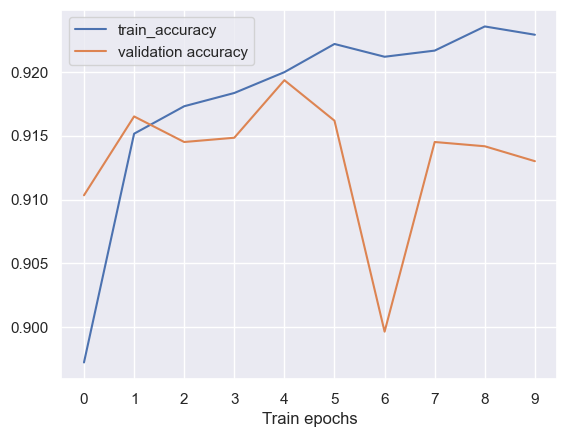


Model built with:
Hidden layers = []
Activation = tanh
Optimizer = Adam
Learning Rate = 0.01
Parameters = 7850
Training accuracy: 0.9229
Validation accuracy: 0.9130


 digits | [] | tanh | Adam | 0.01 | 7850 | 0.9229 | 0.9130
{'data': 'digits', 'hidden_layer_sizes': [], 'activation': 'relu', 'optimizer': 'SGD', 'learning_rate': 0.01}
Training the digits model...


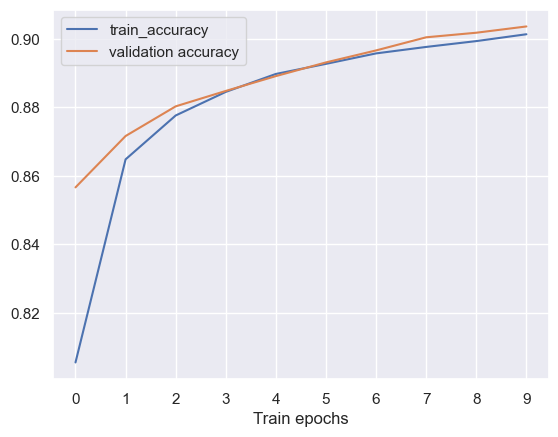


Model built with:
Hidden layers = []
Activation = relu
Optimizer = SGD
Learning Rate = 0.01
Parameters = 7850
Training accuracy: 0.9014
Validation accuracy: 0.9037


 digits | [] | relu | SGD | 0.01 | 7850 | 0.9014 | 0.9037
{'data': 'digits', 'hidden_layer_sizes': [], 'activation': 'relu', 'optimizer': 'Adam', 'learning_rate': 0.01}
Training the digits model...


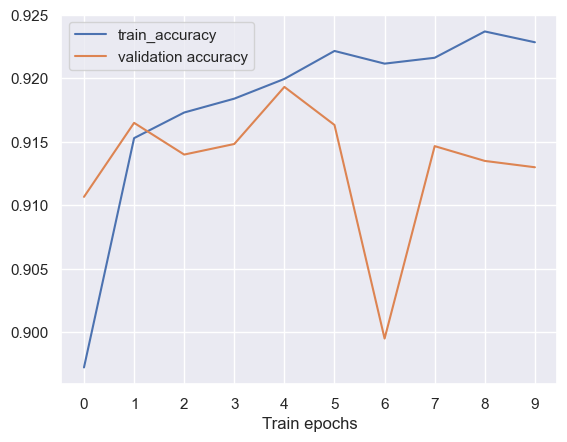


Model built with:
Hidden layers = []
Activation = relu
Optimizer = Adam
Learning Rate = 0.01
Parameters = 7850
Training accuracy: 0.9229
Validation accuracy: 0.9130


 digits | [] | relu | Adam | 0.01 | 7850 | 0.9229 | 0.9130
{'data': 'digits', 'hidden_layer_sizes': [128], 'activation': 'relu', 'optimizer': 'Adam', 'learning_rate': 0.01}
Training the digits model...


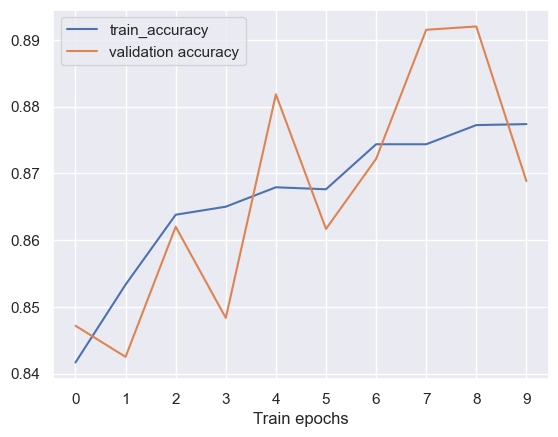


Model built with:
Hidden layers = [128]
Activation = relu
Optimizer = Adam
Learning Rate = 0.01
Parameters = 101770
Training accuracy: 0.8774
Validation accuracy: 0.8688


 digits | [128] | relu | Adam | 0.01 | 101770 | 0.8774 | 0.8688
{'data': 'digits', 'hidden_layer_sizes': [256, 128], 'activation': 'relu', 'optimizer': 'Adam', 'learning_rate': 0.01}
Training the digits model...


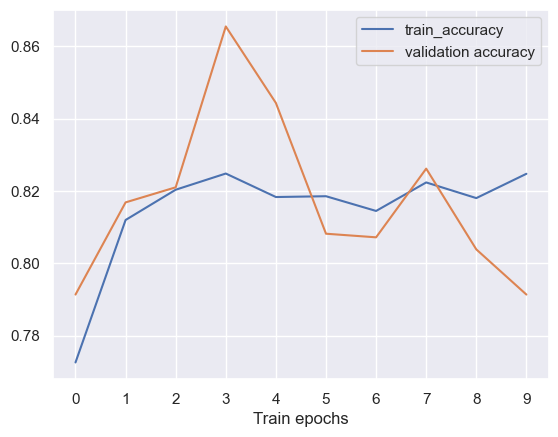


Model built with:
Hidden layers = [256, 128]
Activation = relu
Optimizer = Adam
Learning Rate = 0.01
Parameters = 235146
Training accuracy: 0.8247
Validation accuracy: 0.7913


 digits | [256, 128] | relu | Adam | 0.01 | 235146 | 0.8247 | 0.7913
{'data': 'fashion', 'hidden_layer_sizes': [], 'activation': 'tanh', 'optimizer': 'SGD', 'learning_rate': 0.01}
Training the fashion model...


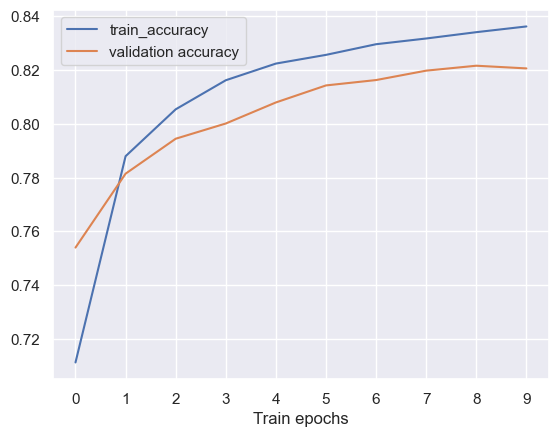


Model built with:
Hidden layers = []
Activation = tanh
Optimizer = SGD
Learning Rate = 0.01
Parameters = 7850
Training accuracy: 0.8363
Validation accuracy: 0.8207


 fashion | [] | tanh | SGD | 0.01 | 7850 | 0.8363 | 0.8207
{'data': 'fashion', 'hidden_layer_sizes': [], 'activation': 'relu', 'optimizer': 'SGD', 'learning_rate': 0.01}
Training the fashion model...


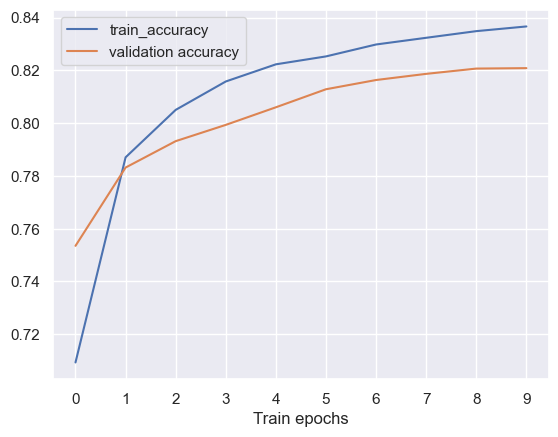


Model built with:
Hidden layers = []
Activation = relu
Optimizer = SGD
Learning Rate = 0.01
Parameters = 7850
Training accuracy: 0.8366
Validation accuracy: 0.8208


 fashion | [] | relu | SGD | 0.01 | 7850 | 0.8366 | 0.8208
{'data': 'fashion', 'hidden_layer_sizes': [], 'activation': 'relu', 'optimizer': 'Adam', 'learning_rate': 0.01}
Training the fashion model...


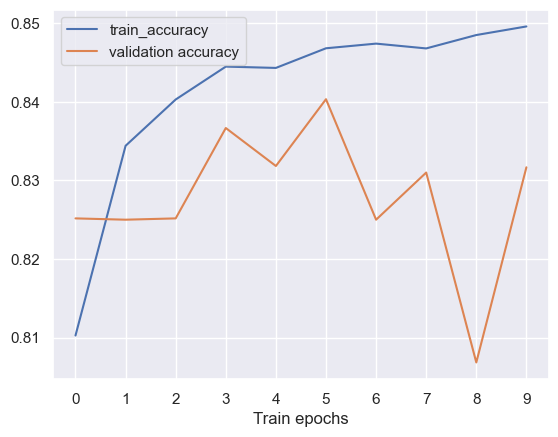


Model built with:
Hidden layers = []
Activation = relu
Optimizer = Adam
Learning Rate = 0.01
Parameters = 7850
Training accuracy: 0.8496
Validation accuracy: 0.8317


 fashion | [] | relu | Adam | 0.01 | 7850 | 0.8496 | 0.8317
{'data': 'fashion', 'hidden_layer_sizes': [128], 'activation': 'relu', 'optimizer': 'Adam', 'learning_rate': 0.01}
Training the fashion model...


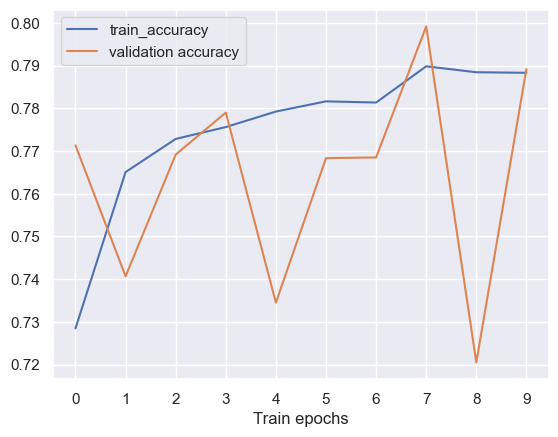


Model built with:
Hidden layers = [128]
Activation = relu
Optimizer = Adam
Learning Rate = 0.01
Parameters = 101770
Training accuracy: 0.7883
Validation accuracy: 0.7892


 fashion | [128] | relu | Adam | 0.01 | 101770 | 0.7883 | 0.7892
{'data': 'fashion', 'hidden_layer_sizes': [256, 128], 'activation': 'relu', 'optimizer': 'Adam', 'learning_rate': 0.01}
Training the fashion model...


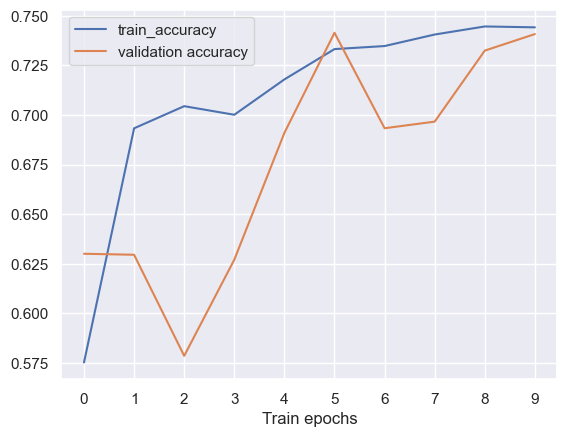


Model built with:
Hidden layers = [256, 128]
Activation = relu
Optimizer = Adam
Learning Rate = 0.01
Parameters = 235146
Training accuracy: 0.7442
Validation accuracy: 0.7408


 fashion | [256, 128] | relu | Adam | 0.01 | 235146 | 0.7442 | 0.7408
Table of Results
Data | Hidden sizes | Activation| Optimizer | Learning rate | #Parameters | Training accuracy| Validation accuracy
-|-|-|-|-|-|-|-
 digits | [] | tanh | Adam | 0.01 | 7850 | 0.9229 | 0.9130
 digits | [] | relu | SGD | 0.01 | 7850 | 0.9014 | 0.9037
 digits | [] | relu | Adam | 0.01 | 7850 | 0.9229 | 0.9130
 digits | [128] | relu | Adam | 0.01 | 101770 | 0.8774 | 0.8688
 digits | [256, 128] | relu | Adam | 0.01 | 235146 | 0.8247 | 0.7913
 fashion | [] | tanh | SGD | 0.01 | 7850 | 0.8363 | 0.8207
 fashion | [] | relu | SGD | 0.01 | 7850 | 0.8366 | 0.8208
 fashion | [] | relu | Adam | 0.01 | 7850 | 0.8496 | 0.8317
 fashion | [128] | relu | Adam | 0.01 | 101770 | 0.7883 | 0.7892
 fashion | [256, 128] | relu | Adam | 0.01 | 235146 

In [13]:
ablation_study = """digits | [] | tanh | Adam | 0.01 | 7850 | 0.1091 | 0.1018
 digits | [] | relu | SGD | 0.01 | 7850 | |
 digits | [] | relu | Adam | 0.01 | 7850 | |
 digits | [128] | relu | Adam | 0.01 | 101770 | |
 digits | [256, 128] | relu | Adam | 0.01 | 235146 | |
 fashion | [] | tanh | SGD | 0.01 | 7850 | |
 fashion | [] | relu | SGD | 0.01 | 7850 | |
 fashion | [] | relu | Adam | 0.01 | 7850 | |
 fashion | [128] | relu | Adam | 0.01 | 101770 | |
 fashion | [256, 128] | relu | Adam | 0.01 | 235146 | |"""

study_results = []
for study in ablation_study.split("\n"):
    input = parse_ablation_row(study)
    print(input)
    model, result = train_and_evaluate(**input)
    study_results.append(result)

print("Table of Results")
print("Data | Hidden sizes | Activation| Optimizer | Learning rate | #Parameters | Training accuracy| Validation accuracy")
print("-|-|-|-|-|-|-|-")
for result in study_results:
    print(result)

---
### Step 6: Evaluation and Generalization

### <span style="color:chocolate">Exercise 4:</span> Compute metrics (25 points)

Now that you've determined the optimal set of hyperparameters, it's time to evaluate your optimized model on the test data to gauge its performance in real-world scenarios, commonly known as inference.

1. Calculate accuracy on both train and test datasets. Note: you will need to convert the vector of predicted probabilities to a class label using the argmax operation. Hint: You can utilize the <span style="color:chocolate">model.predict()</span> method provided by tf.keras and the <span style="color:chocolate">np.max()</span> method available in NumPy; or you can use the <span style="color:chocolate">model.evaluare()</span> method provided by tf.keras directly.

2. Does the model demonstrate strong generalization capabilities? Provide an explanation based on your accuracy observations.

In [14]:
# YOUR CODE HERE